Setup env

In [ ]:
pip install nltk gensim scikit-learn numpy seaborn

In [ ]:
pip install --user --upgrade scipy

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

Data Exploration

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [ ]:
def load_tweet_file(path):
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    if '\n' in content.strip() and content.count('\n') > 5:
        tweets = [line.strip() for line in content.split('\n') if line.strip()]
    else:
        tweets = [t.strip() for t in content.split(',') if t.strip()]
    return pd.DataFrame({'tweets': tweets})

neg = load_tweet_file('../data/processedNegative.csv')
pos = load_tweet_file('../data/processedPositive.csv')
neu = load_tweet_file('../data/processedNeutral.csv')

print(neg.shape, pos.shape, neu.shape)


In [ ]:
neg['label'] = 'Negative'
pos['label'] = 'Positive'
neu['label'] = 'Neutral'

df = pd.concat([neg, pos, neu], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['label'].value_counts())

df.head()

df['label'].value_counts().plot(kind='bar')

In [ ]:
df['char_length'] = df['tweets'].apply(len)

df['word_count'] = df['tweets'].apply(lambda x: len(x.split()))

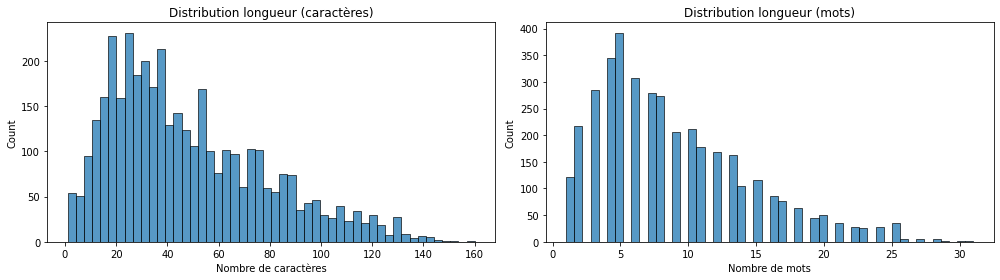

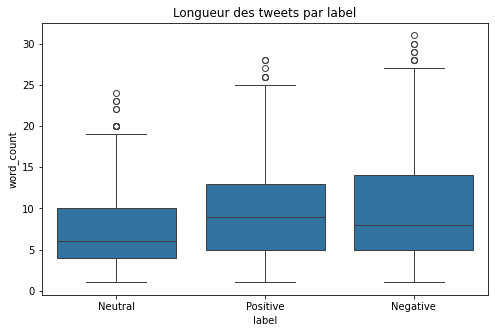

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['char_length'], bins=50, ax=axes[0])
axes[0].set_title('Distribution longueur (caractères)')
axes[0].set_xlabel('Nombre de caractères')

sns.histplot(df['word_count'], bins=50, ax=axes[1])
axes[1].set_title('Distribution longueur (mots)')
axes[1].set_xlabel('Nombre de mots')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Longueur des tweets par label')
plt.show()

In [ ]:
n_dup = df.duplicated(subset='tweets').sum()

print(n_dup)